In [1]:
from pathlib import Path


import pandas as pd
import xarray as xr
from imagematerials.util import dataset_to_array
from imagematerials.vehicles.constants import maintenance_lifetime_per_mode

import matplotlib.pyplot as plt

import warnings
from pathlib import Path

import prism

from imagematerials.concepts import knowledge_graph
from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.model import GenericMainModel, GenericMaterials, GenericStocks
from imagematerials.util import export_to_netcdf, import_from_netcdf, rebroadcast_prep_data
from imagematerials.vehicles import (
    preprocess,
)

In [2]:
base_dir = "../data/raw"
prep_fp = Path("prep_vema.nc")

if not prep_fp.is_file():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        orig_prep_data = preprocess(base_dir)
    export_to_netcdf(orig_prep_data, prep_fp)
prep_data = import_from_netcdf(prep_fp)
share_coords = set()
for cur_type in prep_data["shares"].Type.values:
    share_coords.add(cur_type.split(" - ")[0])
output_coords_type = [x for x in prep_data["stocks"].Type.values if x not in share_coords] + list(prep_data["shares"].coords["Type"].values)
prep_data.pop("shares")
new_prep_data = rebroadcast_prep_data(prep_data, knowledge_graph, dim="Type", output_coords=output_coords_type)
new_prep_data = rebroadcast_prep_data(new_prep_data, knowledge_graph, dim="Region", output_coords=prep_data["stocks"].coords["Region"].values)
new_prep_data["knowledge_graph"] = knowledge_graph

new_prep_data["weights"] = new_prep_data.pop("vehicle_weights")

In [3]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [4]:
# Define the coordinates of all dimensions.
Region = list(prep_data["stocks"].coords["Region"].values)
Time = [t for t in complete_timeline]
Cohort = Time
Type = list(prep_data["stocks"].coords["Type"].values)
material = list(prep_data["material_fractions"].coords["material"].values)

main_model_factory = ModelFactory(
    new_prep_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    ).finish()

In [5]:
warnings.filterwarnings("ignore")
main_model_factory.simulate(simulation_timeline)

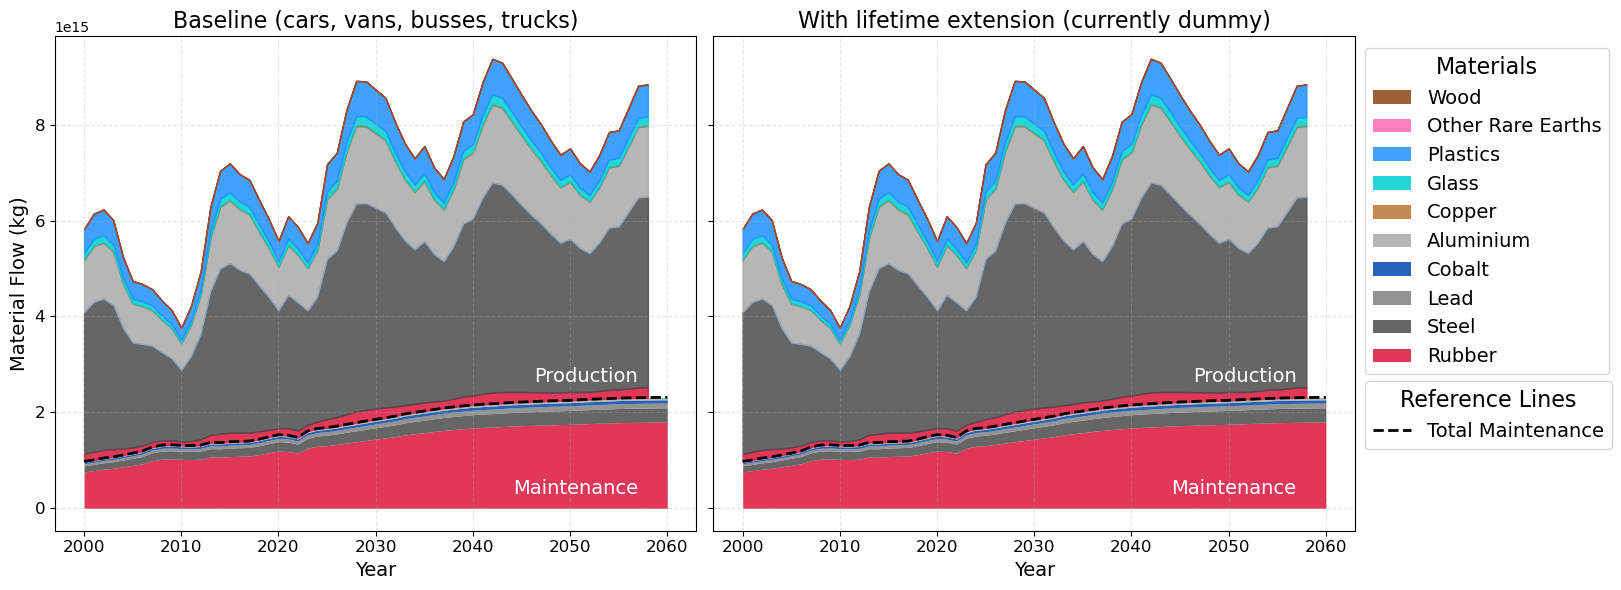

In [6]:
import matplotlib.pyplot as plt

# Define consistent colors
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

# Helper function to sort columns by total sum
def sort_columns_by_sum(df):
    return df.loc[:, df.sum(axis=0).sort_values(ascending=False).index]

# Helper function for a single train type plot
def plot_material_flow(ax, maint_df, prod_df, title):
    # Filter from 1972
    maint_df = maint_df[maint_df.index >= 2000]
    prod_df = prod_df[prod_df.index >= 2000]

    maint_df = sort_columns_by_sum(maint_df)
    prod_df = sort_columns_by_sum(prod_df)
    
    # Keep only non-zero materials across both
    valid_materials = (
        (maint_df != 0).any(axis=0) |
        (prod_df != 0).any(axis=0)
    )
    maint_df = maint_df.loc[:, valid_materials]
    prod_df = prod_df.loc[:, valid_materials]

    # Consistent material order and colors
    materials = maint_df.columns
    colors = [material_colors.get(mat, "#999999") for mat in materials]

    # Plot maintenance
    maint_df.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)
    ax.get_legend().remove()
    maintenance_total = maint_df.sum(axis=1)
    ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

    # Plot production stacked above maintenance
    prod_bottom = maintenance_total.copy()
    for mat in materials:
        top = prod_bottom + prod_df[mat]
        ax.fill_between(
            prod_df.index,
            prod_bottom,
            top,
            #label=f"Production: {mat}",
            color=material_colors.get(mat, "#999999"),
            alpha=0.85,
            #step="mid"
        )
        prod_bottom = top

    # Styling
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Year", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(visible=True, linestyle="--", alpha=0.3)

        # Add 'maintenance' label in bottom right (white)
    ax.text(
        maint_df.index[-1] - 3,                # rightmost year
        ax.get_ylim()[0] + 0.07 * ax.get_ylim()[1],  # just above bottom
        "Maintenance",
        color="white", fontsize=14, ha="right", va="bottom"
    )

    # Add 'maintenance' label just above the dashed line (black)
    ax.text(
        maint_df.index[-1] - 3,
        maintenance_total.iloc[-1] * 1.1,  # just above last value of line
        "Production",
        color="white", fontsize=14, ha="right", va="bottom"
    )


# === Load data ===
# Maintenance and production for both types
prod_df = main_model_factory.inflow_materials.to_array().sum(dim=["Region", "Type"]).to_pandas()

prod_df = prod_df.rolling(window=5, center=True).mean()

maint_df = main_model_factory.inflow_maintenance.to_array().sum(dim=["Region", "Type"]).to_pandas()

rare_earths = ["Nd", "Mn", "Ni", "Ti","Li"]
maint_df["Other Rare Earths"] = maint_df[rare_earths].sum(axis=1)
prod_df["Other Rare Earths"] = prod_df[rare_earths].sum(axis=1)
maint_df = maint_df.drop(columns=rare_earths, errors="ignore")
prod_df = prod_df.drop(columns=rare_earths, errors="ignore")

rename_map = {
    "Pb": "Lead",
    "Co": "Cobalt",
    "Cu": "Copper"
}
maint_df = maint_df.rename(columns=rename_map)
prod_df = prod_df.rename(columns=rename_map)

# === Create side-by-side plot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_material_flow(axes[0], maint_df, prod_df, "Baseline (cars, vans, busses, trucks)")
plot_material_flow(axes[1], maint_df, prod_df, "With lifetime extension (currently dummy)")

# Shared Y label
axes[0].set_ylabel("Material Flow (kg)", fontsize=14)

# Get all handles
all_handles, all_labels = axes[1].get_legend_handles_labels()

# Separate Total Maintenance
material_handles_labels = [(h, l) for h, l in zip(all_handles, all_labels) if not l.startswith("Total")]
maintenance_handles_labels = [(h, l) for h, l in zip(all_handles, all_labels) if l.startswith("Total")]

# Shared legend (outside)
handles, labels = axes[1].get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]
material_handles_labels = list(zip(*material_handles_labels))
fig.legend(material_handles_labels[0][::-1], material_handles_labels[1][::-1],
           title="Materials", bbox_to_anchor=(0.85, 0.64), loc="center left", fontsize=14, title_fontsize=16)

# Total line legend
if maintenance_handles_labels:
    mh, ml = zip(*maintenance_handles_labels)
    fig.legend(mh, ml, title="Reference Lines", bbox_to_anchor=(0.85, 0.3), loc="center left", fontsize=14, title_fontsize=16)

# Layout optimization for slides
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()


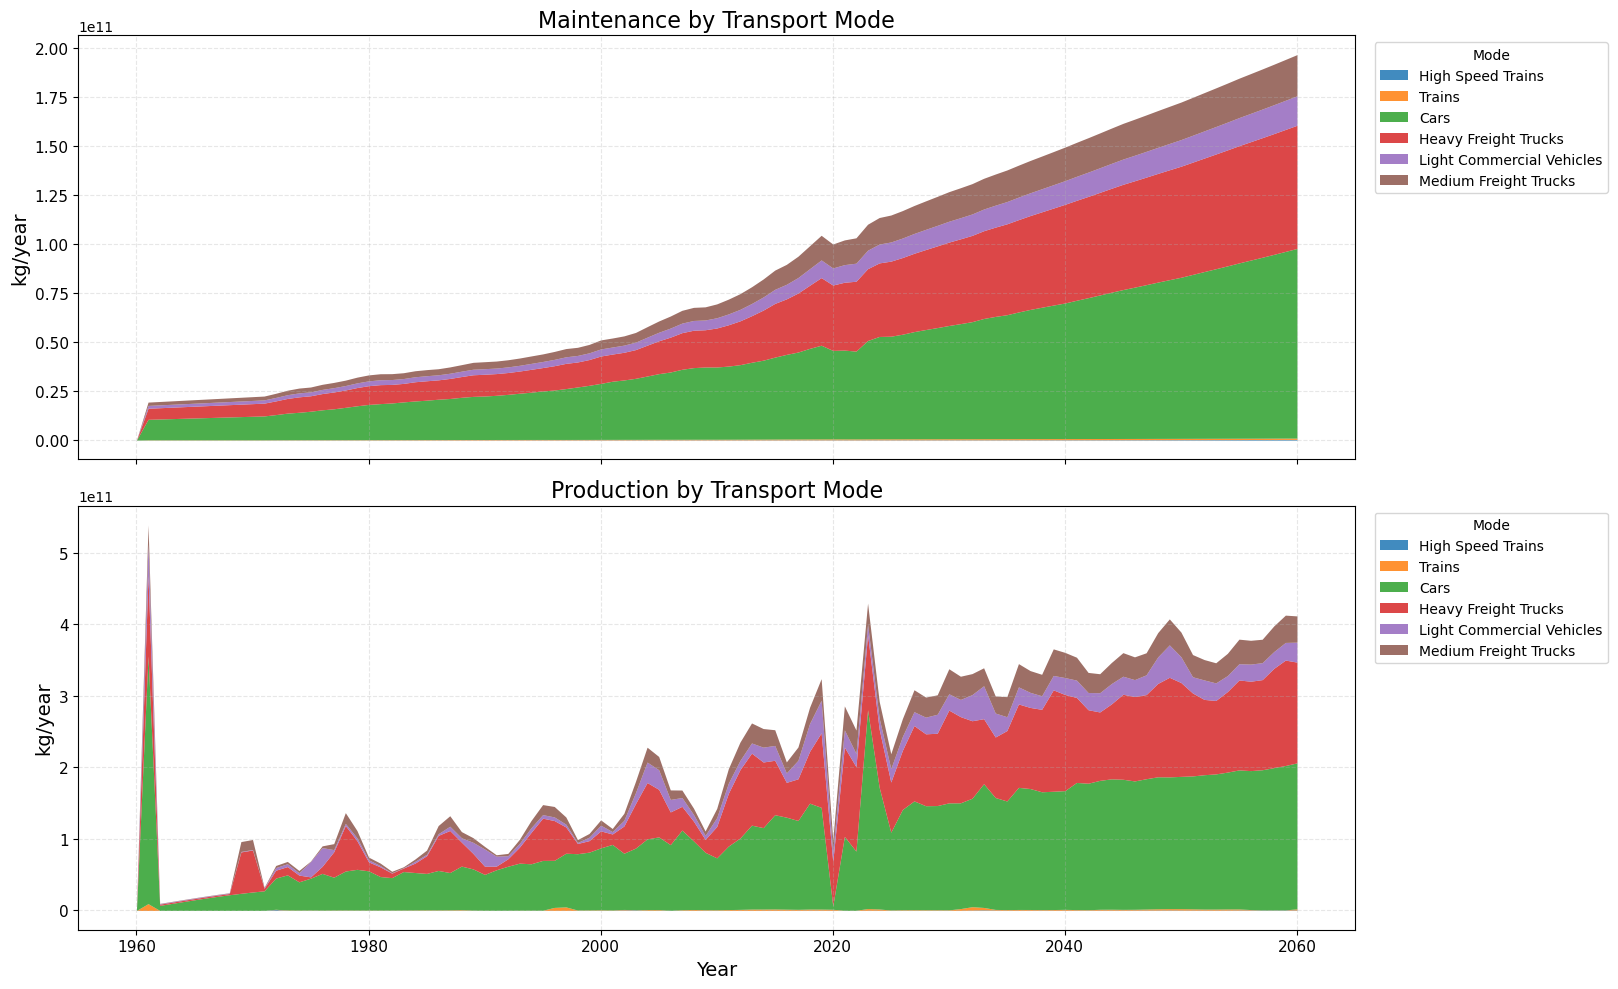

In [87]:
import matplotlib.pyplot as plt

target_types = [
     "High Speed Trains", "Trains", 
    "Cars", "Heavy Freight Trucks", "Light Commercial Vehicles",
    "Medium Freight Trucks", 
]

prod_by_type = main_model_factory.inflow_materials.to_array().sum(dim=["Region", "material"])
maint_by_type = main_model_factory.inflow_maintenance.to_array().sum(dim=["Region", "material"])

prod_by_type = knowledge_graph.rebroadcast_xarray(prod_by_type, output_coords=target_types, dim="Type").to_pandas()
maint_by_type = knowledge_graph.rebroadcast_xarray(maint_by_type, output_coords=target_types, dim="Type").to_pandas()

# Optional: filter years or aggregate if many
prod_df = prod_by_type.loc[prod_by_type.index >=1960]
maint_df = maint_by_type.loc[maint_by_type.index >=1960]

# Plot settings
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Maintenance plot
maint_df.plot.area(ax=axes[0], stacked=True,  alpha=0.85, linewidth=0)
#maint_df.plot(ax=axes[0], kind="bar", stacked=True, width=0.9)
axes[0].set_title("Maintenance by Transport Mode", fontsize=16)
axes[0].set_ylabel("kg/year", fontsize=14)
axes[0].legend(title="Mode", bbox_to_anchor=(1.01, 1), loc="upper left")

# Production plot
prod_df.plot.area(ax=axes[1], stacked=True,  alpha=0.85, linewidth=0)
#prod_df.plot(ax=axes[1], kind="bar", stacked=True, width=0.9)
axes[1].set_title("Production by Transport Mode", fontsize=16)
axes[1].set_xlabel("Year", fontsize=14)
axes[1].set_ylabel("kg/year", fontsize=14)
axes[1].legend(title="Mode", bbox_to_anchor=(1.01, 1), loc="upper left")

# Grid and layout
for ax in axes:
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    ax.tick_params(labelsize=11)
#ax.set_yscale("log")
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Room for legend
plt.show()


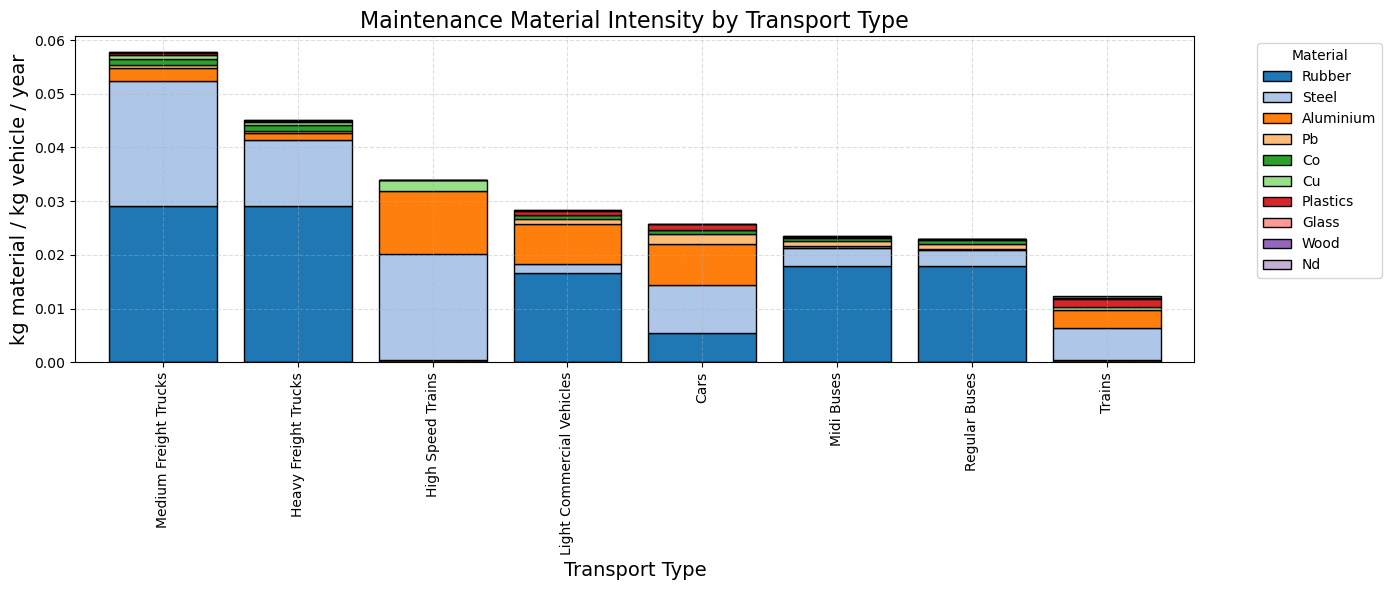

In [7]:
target_types = [
    "Bikes", "Freight Planes", "Freight Trains", "High Speed Trains",
    "Inland Ships", "Large Ships", "Medium Ships", "Passenger Planes",
    "Small Ships", "Trains", "Very Large Ships",
    "Cars", "Heavy Freight Trucks", "Light Commercial Vehicles",
    "Medium Freight Trucks", "Midi Buses", "Regular Buses"
]

maintenace_data = new_prep_data["maintenance_material_fractions"]
rebroadcast_df = knowledge_graph.rebroadcast_xarray(maintenace_data, output_coords=target_types, dim="Type").to_pandas()
rebroadcast_df = rebroadcast_df.loc[
    (rebroadcast_df != 0).any(axis=1),   # Keep rows (Types) with any non-zero
    (rebroadcast_df != 0).any(axis=0)    # Keep columns (Materials) with any non-zero
]
# Sort types (rows) by total maintenance intensity
rebroadcast_df = rebroadcast_df.loc[rebroadcast_df.sum(axis=1).sort_values(ascending=False).index]

# Sort materials (columns) by total across all types
rebroadcast_df = rebroadcast_df[rebroadcast_df.sum(axis=0).sort_values(ascending=False).index]

# Define material colors
material_list = rebroadcast_df.columns.tolist()
material_cmap = plt.get_cmap("tab20")
material_colors = [material_cmap(i) for i in range(len(material_list))]

# Plot
ax = rebroadcast_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    color=material_colors,
    width=0.8,
    edgecolor='black'
)

ax.set_title("Maintenance Material Intensity by Transport Type", fontsize=16)
ax.set_xlabel("Transport Type", fontsize=14)
ax.set_ylabel("kg material / kg vehicle / year", fontsize=14)
ax.legend(title="Material", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(visible=True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
main_model_factory.inflow_materials.to_array().sum(dim=["Region", "material"]).sel(Type = "High Speed Trains")

Magnitude,[0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1210603968.543049 49642492.26614465 18325868.31362551 77738651.32348385 73724704.72908247 31450384.989544656 84809523.21304627 69308635.3796761 36083925.14751655 31322568.146536402 65287165.33318327 53704959.36724597 41028336.64962908 60989370.59181939 69523305.3543443 117937780.48567542 160828247.30811185 126361227.80712914 22132680.510272432 45638800.24000491 80590600.439218 39213978.27575989 63442707.08853634 76988800.79646462 55704979.07899217 60914317.9432344 71297227.44662535 55182975.17702091 38768360.752833575 59881773.260258645 629880735.4587309 647011011.3459458 39707231.453942664 57815895.97856091 104616744.83398387 96409852.90135936 94624159.75098534 70569669.4708211 16453920.104475716 63057703.60526817 80340358.53512028 89618795.4670777 97553782.66405073 121922898.38671552 157818589.7545664 168501029.29380253 243475199.9695839 233706353.22922337 127191011.80870177 5201666.068902495 897505.9902438915 181384998.46423653 179765833.93505412 74323525.63537039 127696553.23536128 140947969.2372812 131805303.55408566 124565739.30738321 112248930.53817588 112653320.95161843 408675889.7541558 741360167.0987438 417185060.70467025 118083593.30586489 202712778.16776082 223320461.72390363 214248572.45322508 208916034.82785293 178985936.65785939 196492731.6167233 231678729.0580303 258301241.08226523 278151681.15573335 299492451.65272135 331949220.5375001 368664370.69050235 423016603.2714632 461146204.69810814 415985735.32122153 318580386.9428904 276671399.96585345 285674574.34675527 342689149.02756023 461632564.63992935 501100257.8037222 409408558.2231163 433324670.1686711 532825298.8862406 555157897.2527809]
Units,count


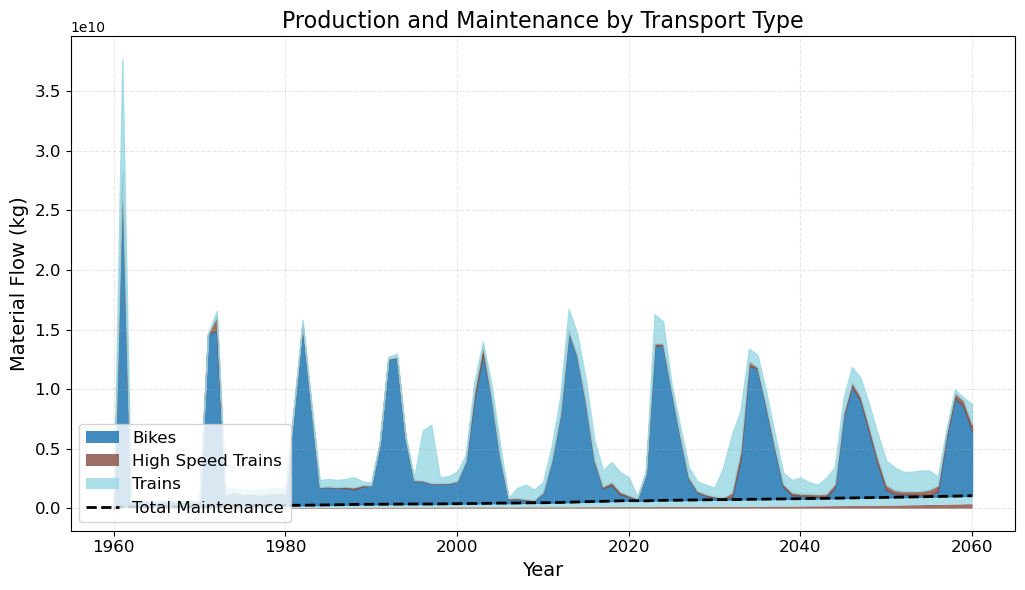

In [61]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === Load data ===

target_types = [
    "Bikes", "High Speed Trains", "Trains", 
]

prod_by_type = main_model_factory.inflow_materials.to_array().sum(dim=["Region", "material"])
maint_by_type = main_model_factory.inflow_maintenance.to_array().sum(dim=["Region", "material"])

prod_by_type = knowledge_graph.rebroadcast_xarray(prod_by_type, output_coords=target_types, dim="Type").to_pandas()
maint_by_type = knowledge_graph.rebroadcast_xarray(maint_by_type, output_coords=target_types, dim="Type").to_pandas()



type_cmap = cm.get_cmap('tab20', len(target_types))  # Choose a colormap with enough unique colors
type_colors = {t: mcolors.to_hex(type_cmap(i)) for i, t in enumerate(target_types)}
colors = [type_colors[t] for t in target_types]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))

# Plot maintenance (bottom layer)
maint_by_type.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)

# Plot total maintenance as dashed black line
maintenance_total = maint_by_type.sum(axis=1)
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2, linestyle="--", label="Total Maintenance")

# Plot production stacked above maintenance
prod_bottom = maintenance_total.copy()
for t in target_types:
    top = prod_bottom + prod_by_type[t]
    ax.fill_between(
        prod_by_type.index,
        prod_bottom,
        top,
        color=type_colors.get(t, "#999999"),
        alpha=0.85
    )
    prod_bottom = top

# Styling
ax.set_title("Production and Maintenance by Transport Type", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Material Flow (kg)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Create legend for types (materials not shown)
from matplotlib.patches import Patch
type_patches = [Patch(color=type_colors[t], label=t) for t in target_types]
legend1 = ax.legend(handles=type_patches, title="Transport Types", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add Total Maintenance to legend
ax.legend(loc="lower left", fontsize=12)
ax.add_artist(legend1)  # Add the first legend manually

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()

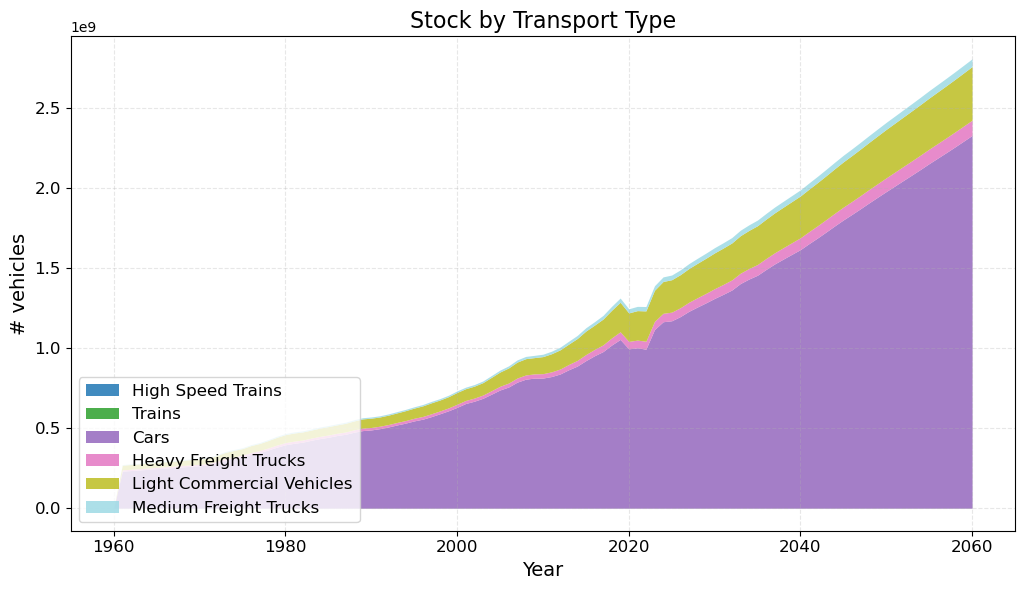

In [71]:
target_types = [
    "High Speed Trains", "Trains", 
    "Cars", "Heavy Freight Trucks", "Light Commercial Vehicles",
    "Medium Freight Trucks", 
]

stock = main_model_factory.stock_by_cohort.sum(dim=["Region", "Cohort"])
stock = knowledge_graph.rebroadcast_xarray(stock, output_coords=target_types, dim="Type").to_pandas()
stock = stock[stock.index >= 1960]

type_cmap = cm.get_cmap('tab20', len(target_types))  # Choose a colormap with enough unique colors
type_colors = {t: mcolors.to_hex(type_cmap(i)) for i, t in enumerate(target_types)}
colors = [type_colors[t] for t in target_types]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))

# Plot maintenance (bottom layer)
stock.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85, linewidth=0)


# Styling
ax.set_title("Stock by Transport Type", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("# vehicles", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Create legend for types (materials not shown)
from matplotlib.patches import Patch
type_patches = [Patch(color=type_colors[t], label=t) for t in target_types]
legend1 = ax.legend(handles=type_patches, title="Transport Types", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add Total Maintenance to legend
ax.legend(loc="lower left", fontsize=12)
ax.add_artist(legend1)  # Add the first legend manually

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legend
plt.show()

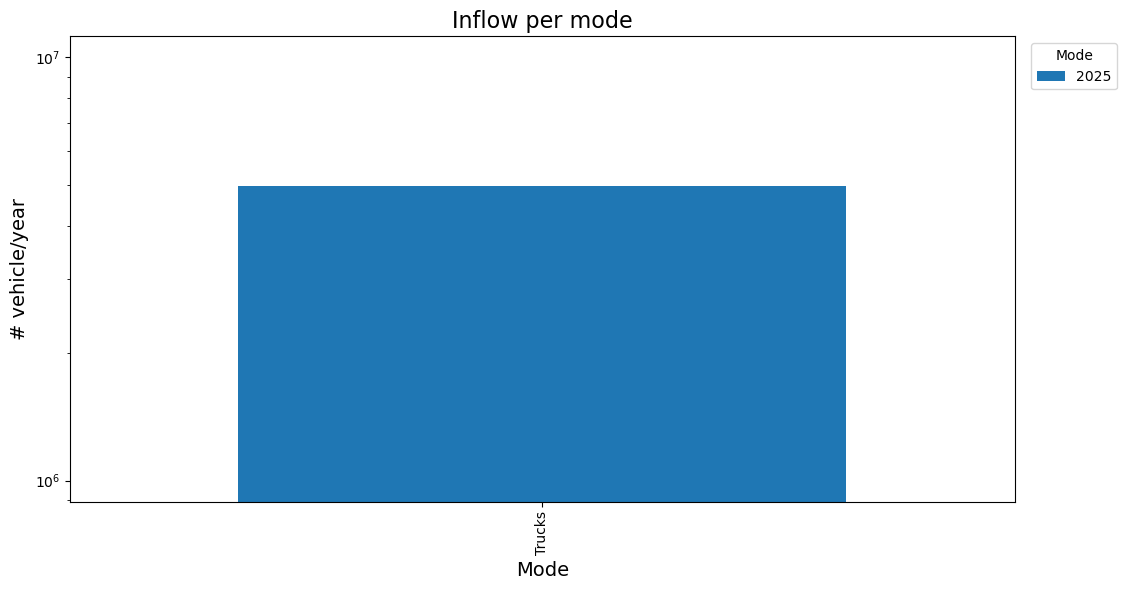

Type,Trucks
time,
1960,0.000000e+00
1961,7.849244e+06
1962,1.207576e+05
1963,1.207576e+05
1964,1.207576e+05
...,...
2056,9.536019e+06
2057,9.614932e+06
2058,1.058751e+07


In [54]:
target_types = [
    "Bikes", "Freight Planes", "Freight Trains", "High Speed Trains",
    "Inland Ships", "Large Ships", "Medium Ships", "Passenger Planes",
    "Small Ships", "Trains", "Very Large Ships",
    "Cars", "Heavy Freight Trucks", "Light Commercial Vehicles",
    "Medium Freight Trucks", "Midi Buses", "Regular Buses"
]
inflow = main_model_factory.inflow.to_array().sum(dim=["Region"])
inflow = knowledge_graph.rebroadcast_xarray(inflow, output_coords=["Trucks"], dim="Type").to_pandas()
inflow = inflow[inflow.index >= 1960]
inflow_2025 =  inflow.loc[2025]
fig, ax = plt.subplots(figsize=(12, 6))
inflow_2025.plot(ax=ax, kind="bar",  width=0.9)
ax.set_title("Inflow per mode", fontsize=16)
ax.set_xlabel("Mode", fontsize=14)
ax.set_ylabel("# vehicle/year", fontsize=14)
ax.legend(title="Mode", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_yscale("log")
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Room for legend
plt.show()

inflow

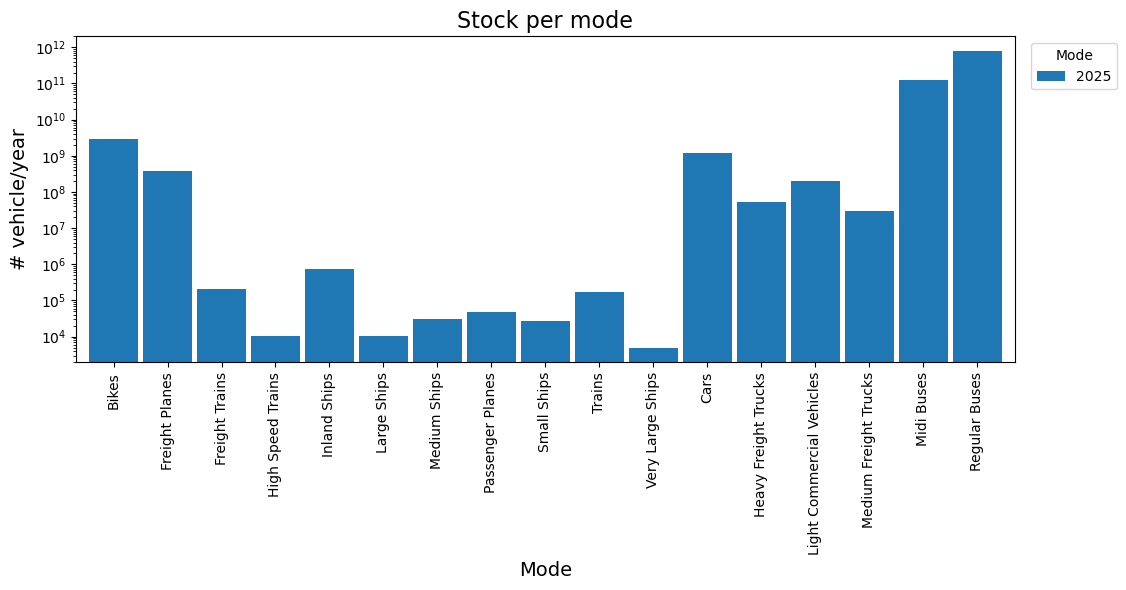

In [ ]:
stock = main_model_factory.stock_by_cohort.sum(dim=["Region", "Cohort"])
stock = knowledge_graph.rebroadcast_xarray(stock, output_coords=target_types, dim="Type").to_pandas()
stock = stock[stock.index >= 1960]

stock_2025 =  stock.loc[2025]
fig, ax = plt.subplots(figsize=(12, 6))
stock_2025.plot(ax=ax, kind="bar",  width=0.9)
ax.set_title("Stock per mode", fontsize=16)
ax.set_xlabel("Mode", fontsize=14)
ax.set_ylabel("# vehicle", fontsize=14)
ax.legend(title="Mode", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_yscale("log")
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Room for legend
plt.show()

In [79]:
maint_by_type

Type,High Speed Trains,Trains,Medium Freight Trucks
time,,,
1960,0.000000e+00,0.000000e+00,0.000000e+00
1961,0.000000e+00,1.235293e+08,1.692348e+09
1962,0.000000e+00,1.244376e+08,1.718384e+09
1963,0.000000e+00,1.253459e+08,1.744420e+09
1964,0.000000e+00,1.262542e+08,1.770456e+09
...,...,...,...
2056,3.309626e+08,6.584473e+08,2.027053e+10
2057,3.444283e+08,6.597545e+08,2.044921e+10
2058,3.589064e+08,6.619479e+08,2.063010e+10


In [ ]:
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",
    "Cobalt": "#0047AB",
    "Cu": "#B87333"
}

In [ ]:
production_long = main_model_factory.inflow_materials.to_array().sum(dim=["Region", "Type","material"]).to_series()
production_long.name ="Production"
production_df_smooth = production_long.rolling(window=5, center=True).mean()

# Sum maintenance inflow over Region and materials
maintenance_long = main_model_factory.inflow_maintenance.to_array().sum(dim=["Region", "Type","material"]).to_series()
maintenance_long.name = "Maintenance"

both = pd.concat([maintenance_long, production_df_smooth], axis=1).iloc[2:-2]

fig, ax = plt.subplots(figsize=(12, 7))
both.plot.area(ax=ax, stacked=True,)
# Labels and title
ax.set_xlabel("Year")
ax.set_ylabel("Material Flow (Mt)")
ax.set_title("Global Production and Maintenance Material Inflow (bus, truck, car, van)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Materials")
plt.tight_layout()
plt.show()

In [ ]:
production_df = main_model_factory.inflow_materials.to_array().sum(dim=["Region", "Type"]).to_pandas()

# Sum maintenance inflow over Region and materials
maintenance_df = main_model_factory.inflow_maintenance.to_array().sum(dim=["Region", "Type"]).to_pandas()

# Filter out zero-only materials
nonzero_materials = (
    (maintenance_df != 0).any(axis=0) |
    (production_df != 0).any(axis=0) 
)

maintenance_df = maintenance_df.loc[:, nonzero_materials]
production_df = production_df.loc[:, nonzero_materials]

# Filter from 1972 onwards
maintenance_df = maintenance_df[maintenance_df.index >= 1972]
production_df = production_df[production_df.index >= 1972]

# Total maintenance sum (used for offset and line)
maintenance_total = maintenance_df.sum(axis=1)

production_df_smooth = production_df.rolling(window=5, center=True).mean()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Ensure consistent material order
all_materials = sorted(set(maintenance_df.columns) | set(production_df.columns))

# 2. Build a consistent colormap
cmap = cm.get_cmap("tab20", len(all_materials))
colors = {mat: cmap(i) for i, mat in enumerate(all_materials)}

# 3. Compute maintenance total
maintenance_total = maintenance_df.sum(axis=1)

# 4. Shift production to sit atop maintenance
production_shifted = production_df.add(maintenance_total, axis=0)

# 5. Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot maintenance layer


production_df_smoo = production_df.rolling(window=5, center=True).mean()
s = production_df_smoo.sum().sort_values(ascending = False)

production_df_smoo = production_df_smoo[s.index]

production_df_smoo.plot.area(
    ax=ax,
    stacked=True,
    color=[colors[mat] for mat in maintenance_df.columns],
    alpha=0.7
)

# Black line separating layers
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=2.5, label="Maintenance Total")



# Labels and formatting
ax.set_xlabel("Year")
ax.set_ylabel("Material Flow (Mt)")
ax.set_title("Maintenance and Production Material Inflow (cars, vans, trucks, busses)")
ax.set_xlim(maintenance_df.index.min(), maintenance_df.index.max())
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Materials")
plt.tight_layout()
plt.show()


In [ ]:
# Pivot back into wide format with multi-index
from matplotlib import cm


pivot_df = combined_df.pivot_table(index="time", columns=["Source", "Material"], values="Value", aggfunc="sum")

# Separate layers
maintenance_plot = pivot_df["Maintenance"]
production_plot = pivot_df["Production"]

# Use consistent colors
all_materials = sorted(set(maintenance_df.columns) | set(production_df.columns))
cmap = cm.get_cmap("tab20", len(all_materials))
colors = {mat: cmap(i) for i, mat in enumerate(all_materials)}

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Maintenance
maintenance_plot.plot.area(
    ax=ax,
    stacked=True,
    color=[colors[mat] for mat in maintenance_plot.columns],
    alpha=0.7
)

# Black line in between
mid_line = maintenance_plot.sum(axis=1)
ax.plot(mid_line.index, mid_line, color="black", linewidth=2.5)

# Production (stacked on top)
production_plot.plot.area(
    ax=ax,
    stacked=True,
    color=[colors[mat] for mat in production_plot.columns],
    alpha=0.7
)

# Final touches
ax.set_xlabel("Year")
ax.set_ylabel("Material Flow (Mt)")
ax.set_title("Combined Material Flow by Source")
ax.set_xlim(pivot_df.index.min(), pivot_df.index.max())
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Materials")
plt.tight_layout()
plt.show()


In [ ]:
# Add a new column to indicate the source
maintenance_long = maintenance_df.copy()
maintenance_long["Source"] = "Maintenance"

production_long = production_df_smooth.copy()
production_long["Source"] = "Production"

# Reset index to bring year into a column
maintenance_long = maintenance_long.reset_index().melt(id_vars=["time", "Source"], var_name="Material", value_name="Value")
production_long = production_long.reset_index().melt(id_vars=["time", "Source"], var_name="Material", value_name="Value")



# Combine into one long DataFrame
combined_df = pd.concat([maintenance_long, production_long], ignore_index=True)

In [ ]:
# Sum general inflow over Region





# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot maintenance materials as stacked area
maintenance_df.plot.area(ax=ax, stacked=True, colormap="tab20", alpha=0.7)

# Plot a thick line on top of maintenance total
ax.plot(maintenance_total.index, maintenance_total, color="black", linewidth=3, label="Total Maintenance")

prod_bottom = maintenance_total.copy()
for material in production_df_smooth.columns:
    top = prod_bottom + production_df_smooth[material]
    ax.fill_between(
        production_df_smooth.index,
        prod_bottom,
        top,
        label=f"Prod: {material}",
        alpha=0.7,
        step="mid"
    )
    prod_bottom = top

# Final touches
ax.set_xlabel("Year")
ax.set_ylabel("Material Flow (Mt)")
ax.set_title("Maintenance and Production Material Flows")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Materials")
plt.tight_layout()
plt.show()



In [ ]:
# Sum over time and material to get total flow per Region × Type


heatmap_data = main_model_factory.inflow_maintenance.to_array().sum(dim=["time","Region"]).to_pandas()

# Plot as heatmap
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=False, cmap="YlGnBu")
plt.title("Total Material Flow by Region and Type")
plt.xlabel("Type")
plt.ylabel("Region")
plt.tight_layout()
plt.show()